### Imports & device

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

print("Torch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.10.0+cu128
Using device: cuda


### PDE Simulator

In [2]:
# =========================
# PDE parameters
# =========================
NX, NY = 32, 32
T = 40
DT = 0.1
D = 0.08
MU = 0.02

np.random.seed(42)
torch.manual_seed(42)

def laplacian_periodic(u):
    """
    2D Laplacian with periodic boundary conditions.
    u: shape (NX, NY)
    """
    return (
        np.roll(u, 1, axis=0) +
        np.roll(u, -1, axis=0) +
        np.roll(u, 1, axis=1) +
        np.roll(u, -1, axis=1) -
        4 * u
    )

def make_gaussian_source(nx=NX, ny=NY, num_blobs=2, amplitude=0.15):
    """
    Generate a smooth spatial source field using Gaussian blobs.
    """
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y, indexing="ij")

    s = np.zeros((nx, ny), dtype=np.float32)
    for _ in range(num_blobs):
        cx, cy = np.random.uniform(0.1, 0.9, size=2)
        sigma = np.random.uniform(0.05, 0.15)
        amp = np.random.uniform(0.05, amplitude)
        s += amp * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
    return s

def make_initial_field(nx=NX, ny=NY):
    """
    Generate a smooth random initial workload field.
    """
    field = make_gaussian_source(nx, ny, num_blobs=np.random.randint(1, 4), amplitude=0.8)
    field += 0.05 * np.random.rand(nx, ny).astype(np.float32)
    return field.astype(np.float32)

def simulate_one_scenario(nx=NX, ny=NY, T=T, dt=DT, D=D, mu=MU):
    """
    Simulate one trajectory:
        dw/dt = D * Laplacian(w) + s(x,y,t) - mu * w

    For now, source term is time-independent for simplicity:
        s(x,y,t) = s(x,y)
    """
    w0 = make_initial_field(nx, ny)
    source = make_gaussian_source(nx, ny, num_blobs=np.random.randint(1, 4), amplitude=0.2)

    w = w0.copy()
    trajectory = [w.copy()]

    for t in range(T - 1):
        lap = laplacian_periodic(w)
        w = w + dt * (D * lap + source - mu * w)
        w = np.maximum(w, 0.0)  # keep workload nonnegative
        trajectory.append(w.copy())

    trajectory = np.stack(trajectory, axis=0)   # shape: (T, NX, NY)
    return w0, source, trajectory

## Generate DeepONet Dataset

In [3]:
# =========================
# DeepONet Dataset Generation
# =========================

NUM_SCENARIOS = 300
POINTS_PER_SCENARIO = 1200  # random (x,y,t) samples from each trajectory

branch_inputs = []
trunk_inputs = []
targets = []

x_grid = np.linspace(0, 1, NX)
y_grid = np.linspace(0, 1, NY)
t_grid = np.linspace(0, 1, T)

for _ in range(NUM_SCENARIOS):
    w0, source, traj = simulate_one_scenario()

    # Branch input: initial field + source field
    branch = np.concatenate([w0.reshape(-1), source.reshape(-1)], axis=0).astype(np.float32)

    for _ in range(POINTS_PER_SCENARIO):
        ti = np.random.randint(0, T)
        i = np.random.randint(0, NX)
        j = np.random.randint(0, NY)

        # Trunk input: coordinate (x, y, t)
        coord = np.array([x_grid[i], y_grid[j], t_grid[ti]], dtype=np.float32)

        fourier = []
        for val in coord:
            fourier.extend([
                val,
                np.sin(2*np.pi*val),
                np.cos(2*np.pi*val),
                np.sin(4*np.pi*val),
                np.cos(4*np.pi*val)
            ])

        trunk = np.array(fourier, dtype=np.float32)

        # Target: scalar value w(x,y,t)
        target = np.array([traj[ti, i, j]], dtype=np.float32)

        branch_inputs.append(branch)
        trunk_inputs.append(trunk)
        targets.append(target)

branch_inputs = np.stack(branch_inputs)
trunk_inputs = np.stack(trunk_inputs)
targets = np.stack(targets)

target_mean = targets.mean()
target_std = targets.std() + 1e-8

targets_norm = (targets - target_mean) / target_std

print("target mean:", target_mean)
print("target std:", target_std)

print("Branch input shape:", branch_inputs.shape)
print("Trunk input shape:", trunk_inputs.shape)
print("Target shape:", targets.shape)

target mean: 0.104794174
target std: 0.14132914
Branch input shape: (360000, 2048)
Trunk input shape: (360000, 15)
Target shape: (360000, 1)


## Dataset and DataLoader

In [4]:
class DeepONetDataset(Dataset):
    def __init__(self, branch_inputs, trunk_inputs, targets):
        self.branch_inputs = torch.tensor(branch_inputs, dtype=torch.float32)
        self.trunk_inputs = torch.tensor(trunk_inputs, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.branch_inputs[idx], self.trunk_inputs[idx], self.targets[idx]


dataset = DeepONetDataset(branch_inputs, trunk_inputs, targets_norm)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 288000
Test size: 72000


## DeepONet Model

In [5]:
class DeepONet(nn.Module):
    def __init__(self, branch_dim, trunk_dim, hidden_dim=256, feature_dim=256):
        super().__init__()

        self.branch_net = nn.Sequential(
            nn.Linear(branch_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim)
        )

        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim)
        )

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        b = self.branch_net(branch_input)
        t = self.trunk_net(trunk_input)
        return torch.sum(b * t, dim=1, keepdim=True) + self.bias

branch_dim = 2 * NX * NY
trunk_dim = 15

model = DeepONet(branch_dim, trunk_dim).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6)

print(model)

DeepONet(
  (branch_net): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
  )
  (trunk_net): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
  )
)


## Training Loop

In [6]:
def train_one_epoch_deeponet(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for branch, trunk, y in loader:
        branch = branch.to(device)
        trunk = trunk.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(branch, trunk)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * branch.size(0)

    return total_loss / len(loader.dataset)


def evaluate_deeponet(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for branch, trunk, y in loader:
            branch = branch.to(device)
            trunk = trunk.to(device)
            y = y.to(device)

            pred = model(branch, trunk)
            loss = criterion(pred, y)

            total_loss += loss.item() * branch.size(0)

    return total_loss / len(loader.dataset)


num_epochs = 100
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch_deeponet(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate_deeponet(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.6e} | Test Loss: {test_loss:.6e}")

Epoch 01/100 | Train Loss: 4.592889e-01 | Test Loss: 2.955950e-01
Epoch 02/100 | Train Loss: 2.257605e-01 | Test Loss: 1.911081e-01
Epoch 03/100 | Train Loss: 1.789968e-01 | Test Loss: 1.640689e-01
Epoch 04/100 | Train Loss: 1.446846e-01 | Test Loss: 1.300914e-01
Epoch 05/100 | Train Loss: 1.165594e-01 | Test Loss: 1.095786e-01
Epoch 06/100 | Train Loss: 1.006936e-01 | Test Loss: 9.658565e-02
Epoch 07/100 | Train Loss: 8.806510e-02 | Test Loss: 8.512710e-02
Epoch 08/100 | Train Loss: 7.831756e-02 | Test Loss: 7.441363e-02
Epoch 09/100 | Train Loss: 6.839544e-02 | Test Loss: 6.698839e-02
Epoch 10/100 | Train Loss: 6.044598e-02 | Test Loss: 5.832418e-02
Epoch 11/100 | Train Loss: 5.535783e-02 | Test Loss: 5.405815e-02
Epoch 12/100 | Train Loss: 5.070226e-02 | Test Loss: 4.999138e-02
Epoch 13/100 | Train Loss: 4.688996e-02 | Test Loss: 4.419081e-02
Epoch 14/100 | Train Loss: 4.338799e-02 | Test Loss: 4.441221e-02
Epoch 15/100 | Train Loss: 4.074148e-02 | Test Loss: 4.030514e-02
Epoch 16/1

## Plot Training Curve

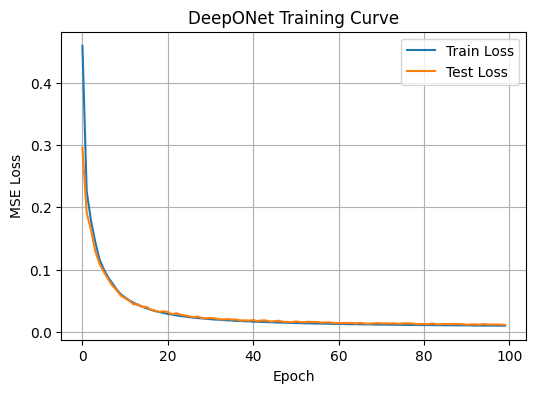

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DeepONet Training Curve")
plt.legend()
plt.grid(True)
plt.show()

## Reconstruct Full Field From DeepONet

In [10]:
def make_fourier_coord(x, y, t):
    coord = np.array([x, y, t], dtype=np.float32)

    fourier = []
    for val in coord:
        fourier.extend([
            val,
            np.sin(2*np.pi*val),
            np.cos(2*np.pi*val),
            np.sin(4*np.pi*val),
            np.cos(4*np.pi*val)
        ])

    return np.array(fourier, dtype=np.float32)


def predict_full_field(model, w0, source, time_index):
    model.eval()

    branch = np.concatenate([w0.reshape(-1), source.reshape(-1)], axis=0).astype(np.float32)
    branch_tensor = torch.tensor(branch, dtype=torch.float32).unsqueeze(0).to(device)

    trunk_list = []
    for i in range(NX):
        for j in range(NY):
            trunk_list.append(
                make_fourier_coord(x_grid[i], y_grid[j], t_grid[time_index])
            )

    trunk_tensor = torch.tensor(np.stack(trunk_list), dtype=torch.float32).to(device)
    branch_tensor = branch_tensor.repeat(NX * NY, 1)

    with torch.no_grad():
        pred = model(branch_tensor, trunk_tensor).cpu().numpy()

    pred = pred * target_std + target_mean  # only keep this if you normalized targets
    return pred.reshape(NX, NY)

## Visualize DeepONet Prediction

t=05 | MSE=1.192792e-03 | Relative L2=0.286146
t=10 | MSE=1.228254e-03 | Relative L2=0.288998
t=20 | MSE=1.774600e-03 | Relative L2=0.336368
t=30 | MSE=2.817891e-03 | Relative L2=0.401182
t=39 | MSE=4.274935e-03 | Relative L2=0.464649


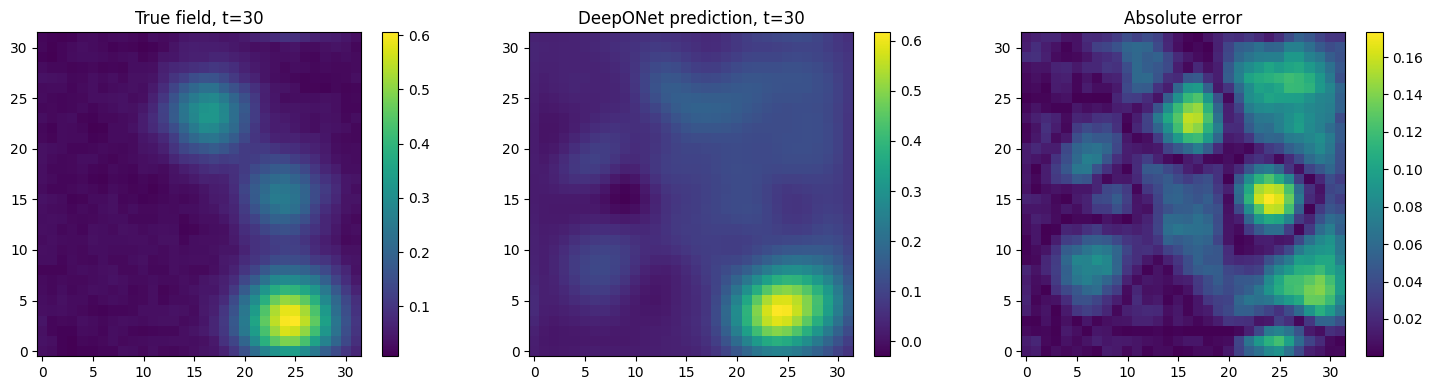

DeepONet sample MSE: 0.002817891
DeepONet sample relative L2: 0.4011821


In [11]:
# Generate unseen test scenario
w0_test, source_test, traj_test = simulate_one_scenario()

# Print error at multiple times
for time_index in [5, 10, 20, 30, 39]:
    pred_field = predict_full_field(model, w0_test, source_test, time_index)
    true_field = traj_test[time_index]

    mse = np.mean((pred_field - true_field) ** 2)
    rel_l2 = np.linalg.norm(pred_field - true_field) / (np.linalg.norm(true_field) + 1e-8)

    print(f"t={time_index:02d} | MSE={mse:.6e} | Relative L2={rel_l2:.6f}")

# Choose ONE time to visualize
time_index = 30

pred_field = predict_full_field(model, w0_test, source_test, time_index)
true_field = traj_test[time_index]
error_field = np.abs(pred_field - true_field)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(true_field, origin="lower")
axes[0].set_title(f"True field, t={time_index}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(pred_field, origin="lower")
axes[1].set_title(f"DeepONet prediction, t={time_index}")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(error_field, origin="lower")
axes[2].set_title("Absolute error")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

mse = np.mean((pred_field - true_field) ** 2)
rel_l2 = np.linalg.norm(pred_field - true_field) / (np.linalg.norm(true_field) + 1e-8)

print("DeepONet sample MSE:", mse)
print("DeepONet sample relative L2:", rel_l2)